In [13]:
import sys
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import StructType,StructField,StringType,IntegerType,DoubleType

spark = (SparkSession.builder
         .appName("check-python")
         .master("local[*]")
         .config("spark.pyspark.python", sys.executable)
         .config("spark.pyspark.driver.python", sys.executable)
         .getOrCreate())

26/02/25 12:02:36 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Pandas выполняет операции на одном узле, а PySpark - на нескольких машинах. Если вы работаете над приложением машинного обучения, где вы имеете дело с большими наборами данных, PySpark обрабатывает операции во много раз быстрее, чем pandas.

После обработки данных в PySpark нам нужно будет преобразовать их обратно в Pandas DataFrame для дальнейшей работы с приложением Machine Learning или любыми приложениями Python.

Ключевые моменты:

Используйте метод toPandas(), доступный в объектах PySpark DataFrame, чтобы преобразовать их в DataFrames.
Pandas DataFrame - это структура данных, хранящаяся в локальной памяти на одном узле, поэтому при преобразовании больших PySpark DataFrames учитывайте нехватку памяти.
Преобразование PySpark DataFrames в Pandas DataFrames позволяет вам использовать широкие функциональные возможности Pandas для манипулирования данными и их анализа.


In [14]:
data = [("James","","Smith","36636","M",60000),
        ("Michael","Rose","","40288","M",70000),
        ("Robert","","Williams","42114","",400000),
        ("Maria","Anne","Jones","39192","F",500000),
        ("Jen","Mary","Brown","","F",0)]

columns = ["first_name","middle_name","last_name","dob","gender","salary"]
df = spark.createDataFrame(data = data, schema = columns)
df.printSchema()
df.show(truncate=False)

root
 |-- first_name: string (nullable = true)
 |-- middle_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- dob: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- salary: long (nullable = true)



+----------+-----------+---------+-----+------+------+
|first_name|middle_name|last_name|dob  |gender|salary|
+----------+-----------+---------+-----+------+------+
|James     |           |Smith    |36636|M     |60000 |
|Michael   |Rose       |         |40288|M     |70000 |
|Robert    |           |Williams |42114|      |400000|
|Maria     |Anne       |Jones    |39192|F     |500000|
|Jen       |Mary       |Brown    |     |F     |0     |
+----------+-----------+---------+-----+------+------+



In [15]:
pdf = df.toPandas()
print(pdf)

  first_name middle_name last_name    dob gender  salary
0      James                 Smith  36636      M   60000
1    Michael        Rose            40288      M   70000
2     Robert              Williams  42114         400000
3      Maria        Anne     Jones  39192      F  500000
4        Jen        Mary     Brown             F       0


In [ ]:
# из Pandas в Pyspark

data = {'col1': [1, 2, 3, 4],
        'col2': ['A', 'B', 'C', 'D']}
pandas_df = pd.DataFrame(data)

pyspark_df = spark.createDataFrame(pandas_df)
pyspark_df.show()

+----+----+
|col1|col2|
+----+----+
|   1|   A|
|   2|   B|
|   3|   C|
|   4|   D|
+----+----+



### Работа со столбцами.

Ключевые моменты:

* Класс PySpark Column -это структура данных, содержащая один столбец в DataFrame.
* Он предоставляет функции, которые чаще всего используются для работы со столбцами DataFrame.
* PySpark предоставляет функции для получения значения из столбца списка по индексу, отображения значения по ключу и индексу и, наконец, структурирования вложенного столбца.
* PySpark также предоставляет дополнительные функции pyspark.sql.functions, которые принимают объект Column и возвращают тип Column.

Примечание: Большинство функций pyspark.sql.functions возвращают класс Column, поэтому очень важно знать, какие операции вы можете выполнять с этим классом.

In [19]:
a = F.lit("column_name")

In [22]:
# разные виды выбора колонки

data = [("James",23),("Ann",40)]
df = spark.createDataFrame(data = data, schema=['name.fname','gender'])
df.printSchema()
df.show()

# Using DataFrame object (df)
df.select('gender').show()
df.select(df.gender).show()
df.select(df["gender"]).show()

#Accessing column name with dot (with backticks)
df.select(df["`name.fname`"]).show()

#Using SQL col() function
from pyspark.sql.functions import col
df.select(col("gender")).show()

#Accessing column name with dot (with backticks)
df.select(col("`name.fname`")).show()

root
 |-- name.fname: string (nullable = true)
 |-- gender: long (nullable = true)

+----------+------+
|name.fname|gender|
+----------+------+
|     James|    23|
|       Ann|    40|
+----------+------+

+------+
|gender|
+------+
|    23|
|    40|
+------+

+------+
|gender|
+------+
|    23|
|    40|
+------+

+------+
|gender|
+------+
|    23|
|    40|
+------+

+----------+
|name.fname|
+----------+
|     James|
|       Ann|
+----------+

+------+
|gender|
+------+
|    23|
|    40|
+------+

+----------+
|name.fname|
+----------+
|     James|
|       Ann|
+----------+



Приведенный ниже пример демонстрирует доступ к столбцам типа struct. Здесь я использовал класс PySpark Row для создания типа struct. Также вы можете создать его с помощью классов PySpark StructType и StructField (об этих структурах расскажу в следующем уроке).

In [ ]:
# Create DataFrame with struct using Row class

from pyspark.sql import Row

data = [Row(name="James",prop=Row(hair="black",eye="blue")),
      Row(name="Ann",prop=Row(hair="grey",eye="black"))]

df = spark.createDataFrame(data)
df.printSchema()
df.show()

# Access struct column
df.select('prop.hair').show()
df.select(df.prop.hair).show()
df.select(df["prop.hair"]).show()
df.select(col("prop.hair")).show()

# Access all columns from struct
df.select(col("prop.*")).show()

root
 |-- name: string (nullable = true)
 |-- prop: struct (nullable = true)
 |    |-- hair: string (nullable = true)
 |    |-- eye: string (nullable = true)

+-----+-------------+
| name|         prop|
+-----+-------------+
|James|{black, blue}|
|  Ann|{grey, black}|
+-----+-------------+

+-----+
| hair|
+-----+
|black|
| grey|
+-----+

+---------+
|prop.hair|
+---------+
|    black|
|     grey|
+---------+

+-----+
| hair|
+-----+
|black|
| grey|
+-----+

+-----+
| hair|
+-----+
|black|
| grey|
+-----+

+-----+-----+
| hair|  eye|
+-----+-----+
|black| blue|
| grey|black|
+-----+-----+



### Функция select()

В PySpark функция select() используется для выбора одного или нескольких столбцов  из DataFrame. PySpark select() - это функция преобразования, поэтому она возвращает новый DataFrame с выбранными столбцами.

In [26]:
spark = SparkSession.builder.getOrCreate()

# Data
data = [("James","Smith","USA","CA"),
    ("Michael","Rose","USA","NY"),
    ("Robert","Williams","USA","CA"),
    ("Maria","Jones","USA","FL")
  ]
columns = ["firstname","lastname","country","state"]
df = spark.createDataFrame(data = data, schema = columns)
df.show()

+---------+--------+-------+-----+
|firstname|lastname|country|state|
+---------+--------+-------+-----+
|    James|   Smith|    USA|   CA|
|  Michael|    Rose|    USA|   NY|
|   Robert|Williams|    USA|   CA|
|    Maria|   Jones|    USA|   FL|
+---------+--------+-------+-----+



* Ниже описаны способы выбора одного, нескольких или всех столбцов.

In [27]:
# Select columns by different ways
df.select("firstname","lastname").show()
df.select(df.firstname,df.lastname).show()
df.select(df["firstname"],df["lastname"]).show()

# By using col() function
df.select(F.col("firstname"),F.col("lastname")).show()

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+

+---------+--------+
|firstname|lastname|
+---------+--------+
|    James|   Smith|
|  Michael|    Rose|
|   Robert|Williams|
|    Maria|   Jones|
+---------+--------+



* Выбор всех столбцов из списка

In [28]:
# Select All columns from List
df.select(*columns).show()

# Select All columns
df.select([col for col in df.columns]).show()
df.select("*").show()

+---------+--------+-------+-----+
|firstname|lastname|country|state|
+---------+--------+-------+-----+
|    James|   Smith|    USA|   CA|
|  Michael|    Rose|    USA|   NY|
|   Robert|Williams|    USA|   CA|
|    Maria|   Jones|    USA|   FL|
+---------+--------+-------+-----+

+---------+--------+-------+-----+
|firstname|lastname|country|state|
+---------+--------+-------+-----+
|    James|   Smith|    USA|   CA|
|  Michael|    Rose|    USA|   NY|
|   Robert|Williams|    USA|   CA|
|    Maria|   Jones|    USA|   FL|
+---------+--------+-------+-----+

+---------+--------+-------+-----+
|firstname|lastname|country|state|
+---------+--------+-------+-----+
|    James|   Smith|    USA|   CA|
|  Michael|    Rose|    USA|   NY|
|   Robert|Williams|    USA|   CA|
|    Maria|   Jones|    USA|   FL|
+---------+--------+-------+-----+



* Выбор столбцов по индексу

In [29]:
#Selects first 3 columns and top 3 rows
df.select(df.columns[:3]).show(3)

#Selects columns 2 to 4  and top 3 rows
df.select(df.columns[2:4]).show(3)

+---------+--------+-------+
|firstname|lastname|country|
+---------+--------+-------+
|    James|   Smith|    USA|
|  Michael|    Rose|    USA|
|   Robert|Williams|    USA|
+---------+--------+-------+
only showing top 3 rows
+-------+-----+
|country|state|
+-------+-----+
|    USA|   CA|
|    USA|   NY|
|    USA|   CA|
+-------+-----+
only showing top 3 rows


* Операции над столбцами в PySpark

In [31]:
data=[(100,2,1),(200,3,4),(300,4,4)]
df=spark.createDataFrame(data).toDF("col1","col2","col3")

#Arthmetic operations
df.select(df.col1 + df.col2).show()
df.select(df.col1 % df.col2).show()

df.select(df.col2 > df.col3).show()
df.select(df.col2 < df.col3).show()
df.select(df.col2 == df.col3).show()

+-------------+
|(col1 + col2)|
+-------------+
|          102|
|          203|
|          304|
+-------------+

+-------------+
|(col1 % col2)|
+-------------+
|            0|
|            2|
|            0|
+-------------+

+-------------+
|(col2 > col3)|
+-------------+
|         true|
|        false|
|        false|
+-------------+

+-------------+
|(col2 < col3)|
+-------------+
|        false|
|         true|
|        false|
+-------------+

+-------------+
|(col2 = col3)|
+-------------+
|        false|
|        false|
|         true|
+-------------+



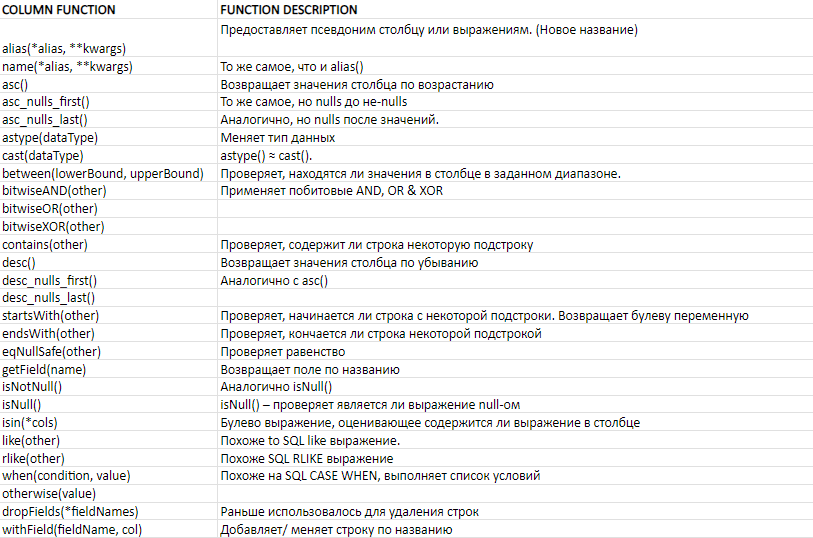

In [40]:
data=[("James","Bond","100",None),
      ("Ann","Varsa","200",'F'),
      ("Tom Cruise","XXX","400",''),
      ("Tom Brand",None,"400",'M')] 
columns=["fname","lname","id","gender"]
df=spark.createDataFrame(data,columns)
df.show()

+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|     James| Bond|100|  NULL|
|       Ann|Varsa|200|     F|
|Tom Cruise|  XXX|400|      |
| Tom Brand| NULL|400|     M|
+----------+-----+---+------+



In [ ]:
# alias
df.select(df.fname.alias("first_name"), \
          df.lname.alias("last_name")).show()

# expr() для объединения столбцов и назвал столбец fullName.
df.select(F.expr("fname || ' ' || lname").alias("fullname")).show()

+----------+---------+
|first_name|last_name|
+----------+---------+
|     James|     Bond|
|       Ann|    Varsa|
|Tom Cruise|      XXX|
| Tom Brand|     NULL|
+----------+---------+

+--------------+
|      fullname|
+--------------+
|    James Bond|
|     Ann Varsa|
|Tom Cruise XXX|
|          NULL|
+--------------+



In [42]:
# asc() & desc() - сортировка столбцов DataFrame по возрастанию или убыванию.

df.sort(df.fname.asc()).show()
df.sort(df.fname.desc()).show()

+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|       Ann|Varsa|200|     F|
|     James| Bond|100|  NULL|
| Tom Brand| NULL|400|     M|
|Tom Cruise|  XXX|400|      |
+----------+-----+---+------+

+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|Tom Cruise|  XXX|400|      |
| Tom Brand| NULL|400|     M|
|     James| Bond|100|  NULL|
|       Ann|Varsa|200|     F|
+----------+-----+---+------+



In [46]:
# contains() - проверяет, содержит ли значение столбца PySpark DataFrame строковое значение, указанное в этой функции.

df.filter(df.fname.contains("Cruise")).show()

+----------+-----+---+------+
|     fname|lname| id|gender|
+----------+-----+---+------+
|Tom Cruise|  XXX|400|      |
+----------+-----+---+------+



In [47]:
spark.stop()